# Загрузка данных

In [1]:
import pandas as pd

df = pd.read_csv('pulsar_stars.csv')
new_columns = {
    "Mean of the integrated profile": "IP_mean",
    "Standard deviation of the integrated profile": "IP_std",
    "Excess kurtosis of the integrated profile": "IP_kurtosis",
    "Skewness of the integrated profile": "IP_skew",
    "Mean of the DM-SNR curve": "DM_SNR_mean",
    "Standard deviation of the DM-SNR curve": "DM_SNR_std",
    "Excess kurtosis of the DM-SNR curve": "DM_SNR_kurtosis",
    "Skewness of the DM-SNR curve": "DM_SNR_skew",
    "target_class": "target"
}

df = df.rename(columns=new_columns)
df


,IP_mean,IP_std,IP_kurtosis,IP_skew,DM_SNR_mean,DM_SNR_std,DM_SNR_kurtosis,DM_SNR_skew,target
0,140.562500,55.683782,-0.234571,-0.699648,3.199833,19.110426,7.975532,74.242225,0
1,102.507812,58.882430,0.465318,-0.515088,1.677258,14.860146,10.576487,127.393580,0
2,103.015625,39.341649,0.323328,1.051164,3.121237,21.744669,7.735822,63.171909,0
3,136.750000,57.178449,-0.068415,-0.636238,3.642977,20.959280,6.896499,53.593661,0
4,88.726562,40.672225,0.600866,1.123492,1.178930,11.468720,14.269573,252.567306,0
...,...,...,...,...,...,...,...,...,...
17893,136.429688,59.847421,-0.187846,-0.738123,1.296823,12.166062,15.450260,285.931022,0
17894,122.554688,49.485605,0.127978,0.323061,16.409699,44.626893,2.945244,8.297092,0
17895,119.335938,59.935939,0.159363,-0.743025,21.430602,58.872000,2.499517,4.595173,0
17896,114.507812,53.902400,0.201161,-0.024789,1.946488,13.381731,10.007967,134.238910,0


# Анализ распределения целевой переменной

Пропущенные значения:
 IP_mean            0
IP_std             0
IP_kurtosis        0
IP_skew            0
DM_SNR_mean        0
DM_SNR_std         0
DM_SNR_kurtosis    0
DM_SNR_skew        0
target             0
dtype: int64

Баланс классов:
 target
0    16259
1     1639
Name: count, dtype: int64


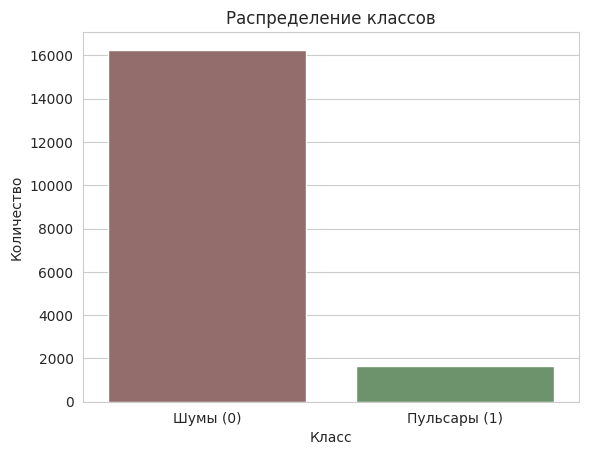

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

# Проверяем пропуски
print("Пропущенные значения:\n", df.isnull().sum())

# Баланс классов
print("\nБаланс классов:\n", df['target'].value_counts())

sns.countplot(x='target', data=df, hue='target', palette={0: "#996666", 1: "#669966"}, legend=False)
plt.title("Распределение классов")
plt.xlabel("Класс")
plt.ylabel("Количество")
plt.xticks([0, 1], ['Шумы (0)', 'Пульсары (1)'])
plt.show()

Значительный дисбаланс классов - объекты, классифицированные как пульсары, составляют всего около 9% от общего объема выборки.

# Исследование признаков и разделимости классов

**Интегрированный профиль пульсара (IP)**
– это усредненный по времени сигнал, полученный за несколько периодов вращения. Такое усреднение (когерентное накопление) способствует увеличению отношения сигнал/шум и позволяет выявить устойчивые характеристики излучения.


**DM-SNR кривая (Dispersion Measure Signal-to-Noise Ratio Curve)**
показывает, как отношение сигнал/шум (SNR) изменяется при разной дисперсионной мере (DM).

*Когда радиосигнал пульсара проходит через космическую среду, электроны замедляют низкие частоты сильнее, чем высокие.
Этот эффект называется дисперсионной задержкой и описывается через параметр DM (Dispersion Measure).
Кривая строится путем варьирования DM и анализа изменения SNR - максимальное значение SNR соответствует истинной мере дисперсии пульсара.*

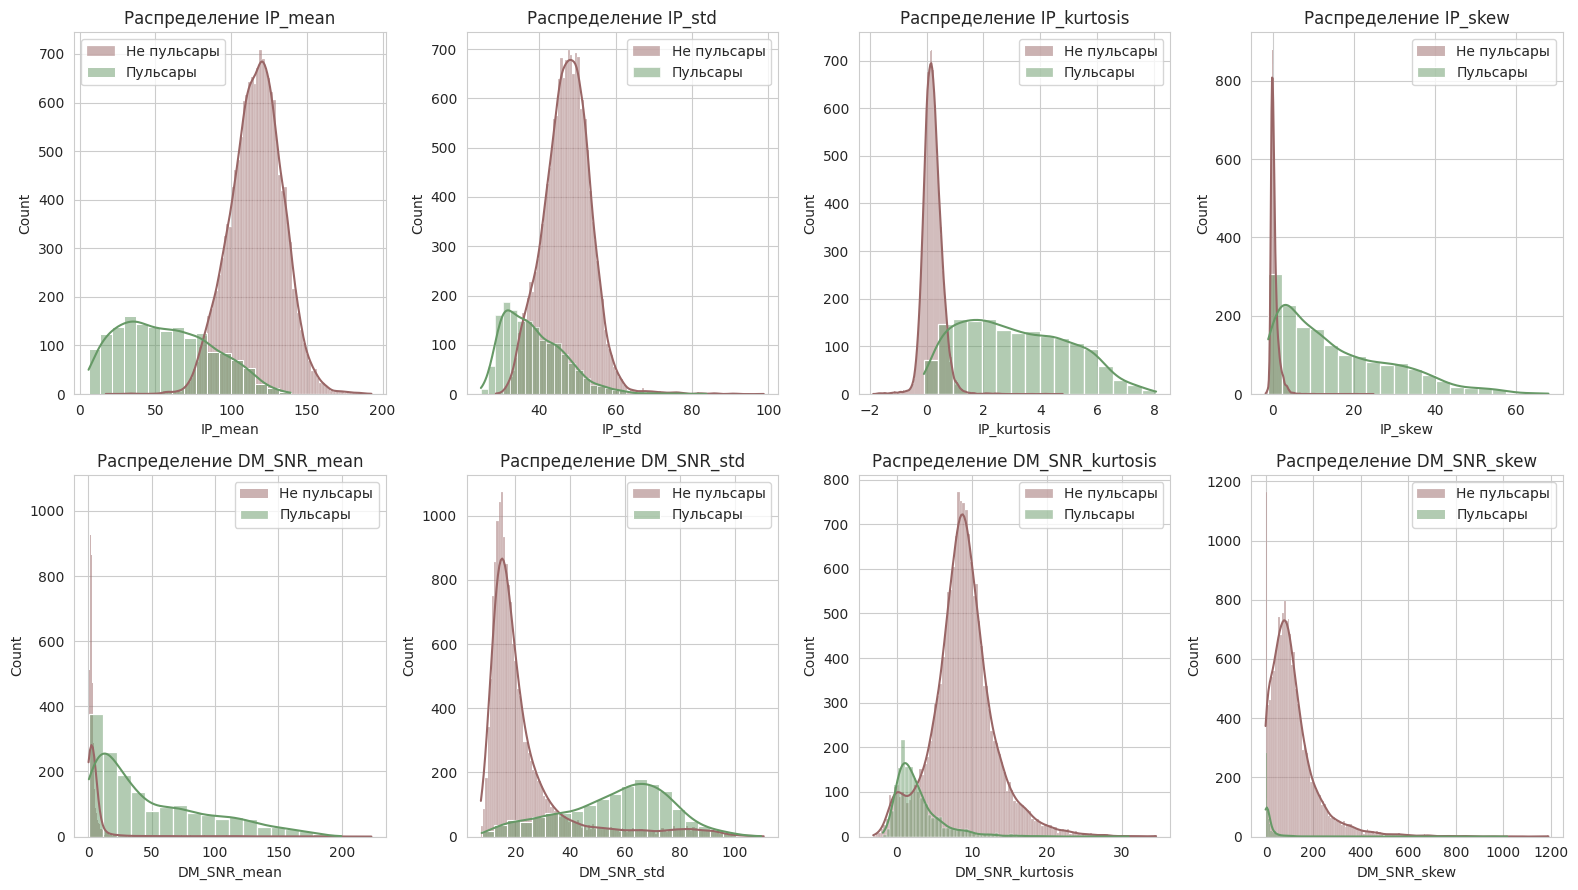

In [38]:
features = df.columns[:-1]  # Все столбцы, кроме последнего

# Гистограммы распределения переменных
plt.figure(figsize=(16, 9))
for i, col in enumerate(features):
  plt.subplot(2, 4, i + 1)
  sns.histplot(df[df['target'] == 0][col], color="#996666", label="Не пульсары", kde=True)
  sns.histplot(df[df['target'] == 1][col], color="#669966", label="Пульсары", kde=True)
  plt.legend()
  plt.title(f'Распределение {col}')
plt.tight_layout()
plt.show()

Признаки `IP_mean`, `IP_kurtosis` и `DM_SNR_mean` показывают наиболее выраженное различие между классами. Пульсары смещены в область меньших значений среднего профиля и более высоких значений эксцесса.

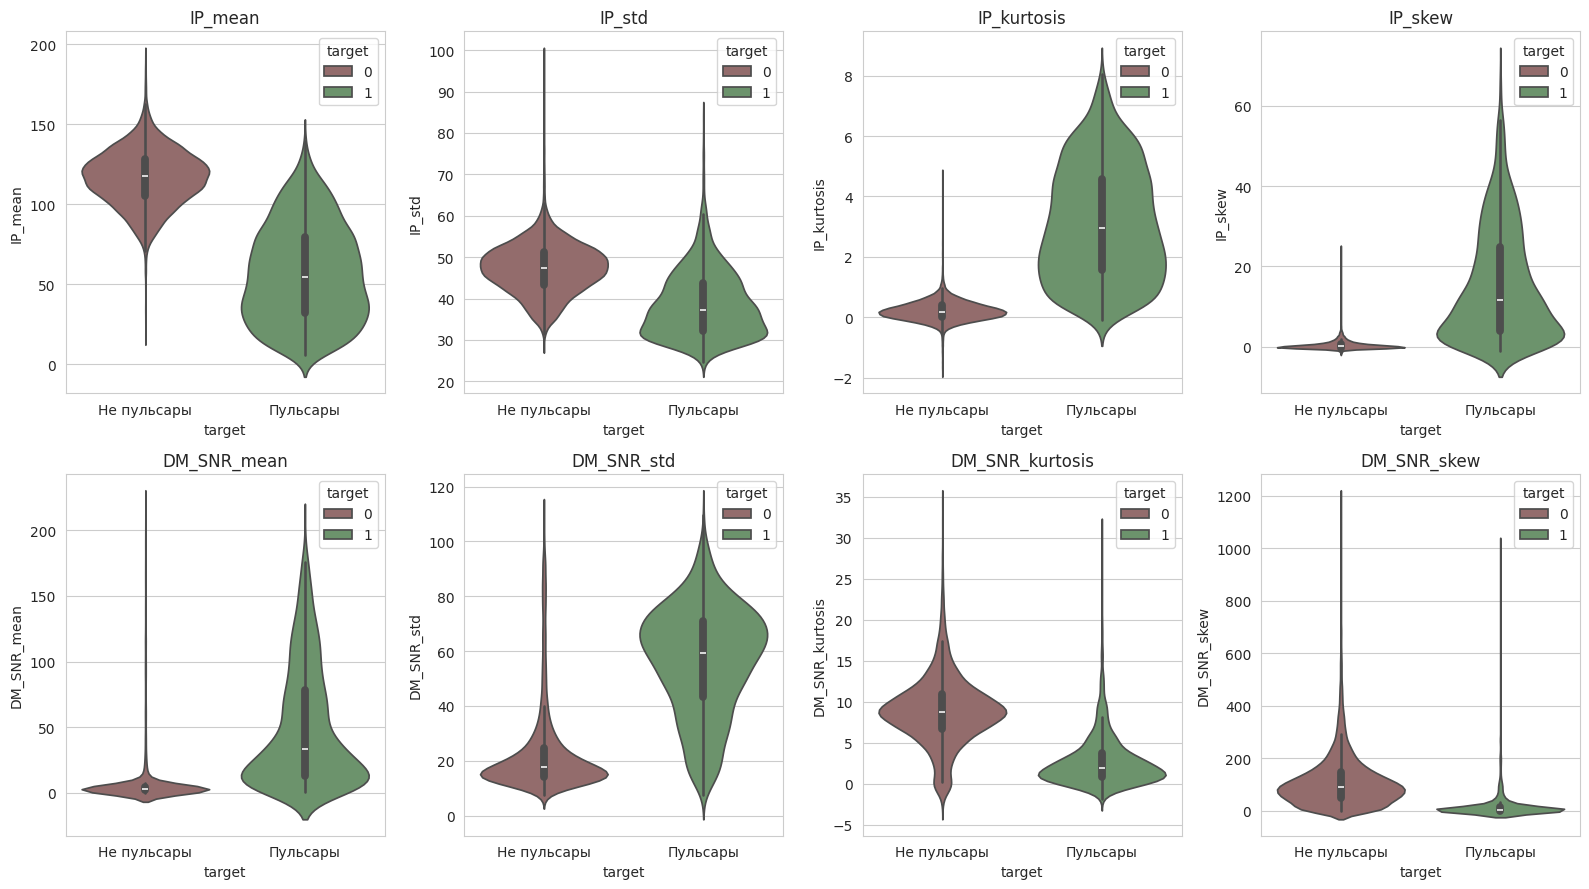

In [32]:
# Violin Plot (распределение значений внутри классов)
plt.figure(figsize=(16, 9))
for i, col in enumerate(features):
  plt.subplot(2, 4, i + 1)
  sns.violinplot(x=df['target'], y=df[col], hue=df['target'], palette=["#996666", "#669966"])
  plt.title(col)
  plt.xticks([0, 1], ['Не пульсары', 'Пульсары'])
plt.tight_layout()
plt.show()

В данных присутствуют экстремальные значения, что для радиоастрономических наблюдений типично. Это подтверждает необходимость стандартизации данных перед обучением моделей.

# Анализ взаимосвязи признаков

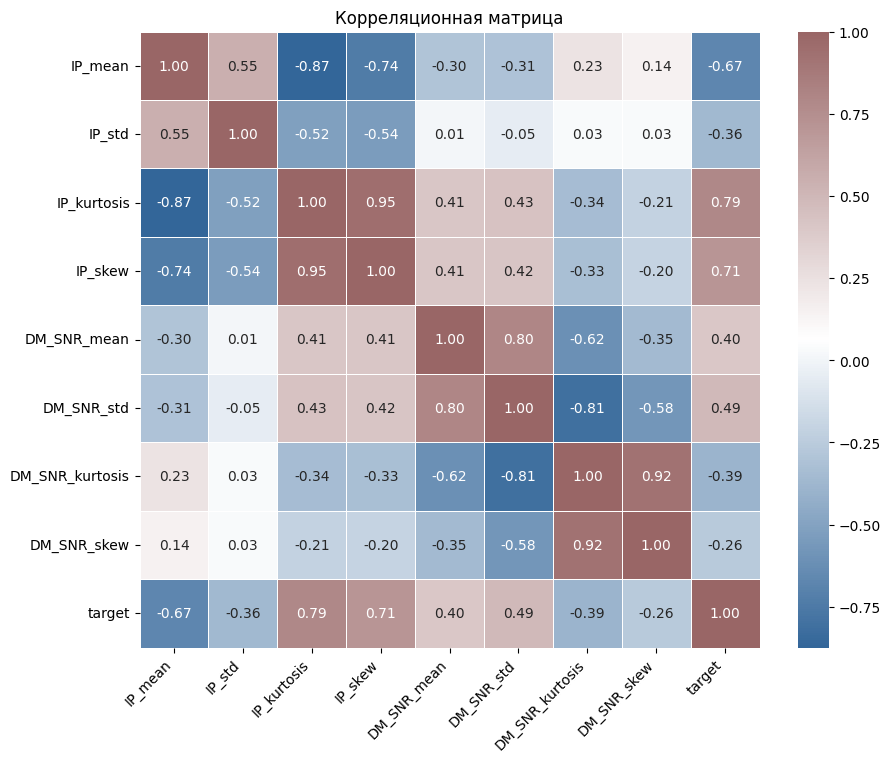

In [5]:
from matplotlib.colors import LinearSegmentedColormap
custom_corr_cmap = LinearSegmentedColormap.from_list("custom_blue_red", ["#336699", "#FFFFFF", "#996666"])

plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap=custom_corr_cmap, fmt=".2f", linewidths=0.5)
plt.xticks(rotation=45, ha='right')
plt.title("Корреляционная матрица")
plt.show()


Между асимметрией интегрированного профиля (`IP_skew`) и его эксцессом (`IP_kurtosis`) высокая линейная зависимость (коэффициент корреляции 0.95), аналогичная картина (коэффициент корреляции 0.92) наблюдается между асимметрией и эксцессом DM SNR (`DM_SNR_skew` и `DM_SNR_kurtosis`).
Такие значения указывают на избыточность информации. Использование сильно зависимых признаков затрудняет интерпретацию линейных моделей и повышает риск переобучения.

Было принято решение исключить параметры асимметрии (`IP_skew` и `DM_SNR_skew`), так как эксцесс его корреляция с целевой переменной выше, что делает его более информативным для разделения классов.

# Подготовка данных перед обучением

Разделение признаков и классов

In [2]:
X = df.drop(columns=['target', 'IP_skew', 'DM_SNR_skew'])
y = df['target']

Разделение на train/test

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print(f"Размер обучающей выборки: {X_train.shape[0]}")
print(f"Размер тестовой выборки: {X_test.shape[0]}")

Размер обучающей выборки: 14318
Размер тестовой выборки: 3580


Стандартизация

In [4]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

scaler = StandardScaler() # Cреднее значение 0 и стандартное отклонение 1

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # Применяем тот же scaler

X = pd.DataFrame(X_train, columns=X.columns)

print("\nСтатистика после нормализации:")
pd.DataFrame(X, columns=df.drop('target', axis=1).columns).describe()



Статистика после нормализации:


,IP_mean,IP_std,IP_kurtosis,IP_skew,DM_SNR_mean,DM_SNR_std,DM_SNR_kurtosis,DM_SNR_skew
count,14318.000000,14318.000000,14318.000000,0.0,14318.000000,14318.000000,14318.000000,0.0
mean,111.057356,46.514924,0.478051,NaN,12.364603,26.238077,8.329605,NaN
std,25.584162,6.805455,1.062676,NaN,28.815515,19.397395,4.506975,NaN
min,5.812500,24.772042,-1.876011,NaN,0.213211,7.370432,-3.139270,NaN
25%,100.876953,42.358552,0.027044,NaN,1.916388,14.405404,5.796108,NaN
50%,115.066406,46.941288,0.224134,NaN,2.795151,18.452507,8.439353,NaN
75%,127.140625,51.023799,0.471585,NaN,5.419941,28.349876,10.731135,NaN
max,192.617188,91.808628,8.069522,NaN,222.421405,110.642211,34.539844,NaN


Балансировка данных

In [ ]:
# from imblearn.over_sampling import SMOTE, ADASYN
# from imblearn.under_sampling import RandomUnderSampler
# from imblearn.pipeline import Pipeline

# pipeline = Pipeline([
#     ('adasyn', ADASYN(sampling_strategy=0.7, random_state=42)),  # Генерируем новые примеры класса 1
#     ('undersample', RandomUnderSampler(sampling_strategy=0.8, random_state=42))  # Удаляем часть класса 0
# ])

# X_train, y_train = pipeline.fit_resample(X_train, y_train)
# # X_test, y_test = pipeline.fit_resample(X_test, y_test)

# print("Баланс классов после балансировки:")
# print(pd.Series(y_train).value_counts())


Были проведены попытки искусственной балансировки классов для выравнивания выборки. Однако применение алгоритмов синтеза новых примеров (ADASYN) и случайного удаления мажоритарного класса не привело к улучшению метрик на тестовой выборке. Напротив, наблюдался рост числа ложных срабатываний (FP).

Вывод - искусственное изменение баланса нарушает естественную структуру распределения признаков, характерную для реальных астрофизических сигналов.

В связи с этим было принято решение отказаться от балансировки в пользу использования встроенных весовых коэффициентов моделей, которые корректируют функцию потерь без искажения самих данных.

# Выбор метрик

Из-за серьезного дисбаланса классов использование accuracy будет некорректным => при обучении моделей будет применен метод балансировки весов, а в качестве основных метрик выбраны:

* Recall (полнота). Снижение количества ложноотрицательных ответов (FN) наиболее важно, так как пропуск сигнала означает потерю потенциального научного открытия. Мы стремимся минимизировать количество пропусков, чтобы поймать как можно больше кандидатов.
* Precision (точность) показывает, насколько часто модель ошибается, принимая шум за пульсар. Высокий уровень точности необходим для минимизации временных затрат на ручную проверку ложных срабатываний. Низкая точность приведет к тому, что придется тратить слишком много времени на проверку ложных сигналов.
* F1-Score - гармоническое среднее между точностью и полнотой. Используем для поиска оптимального баланса: нужен максимальный recall, но избегая перекоса модели в сторону одного показателя.
* PR-AUC - площадь под Precision-Recall кривой. Не учитывает истинноотрицательные ответы (TN) (огромное количество правильно распознанного шума), фокусируясь только на качестве поиска пульсаров, подходящий индикатор качества модели при сильном дисбалансе классов,
* MCC (коэффициент корреляции Мэтьюза) - дает наиболее объективную оценку качества бинарной классификации в условиях несбалансированной выборки, учитывая все сегменты матрицы ошибок. (если MCC высокий — значит, модель одинаково хорошо понимает и шум, и пульсары)

# Базовое обучение (Baseline)

### Логистическая регрессия

              precision    recall  f1-score   support

           0       0.99      0.98      0.98      3252
           1       0.80      0.92      0.86       328

    accuracy                           0.97      3580
   macro avg       0.90      0.95      0.92      3580
weighted avg       0.97      0.97      0.97      3580



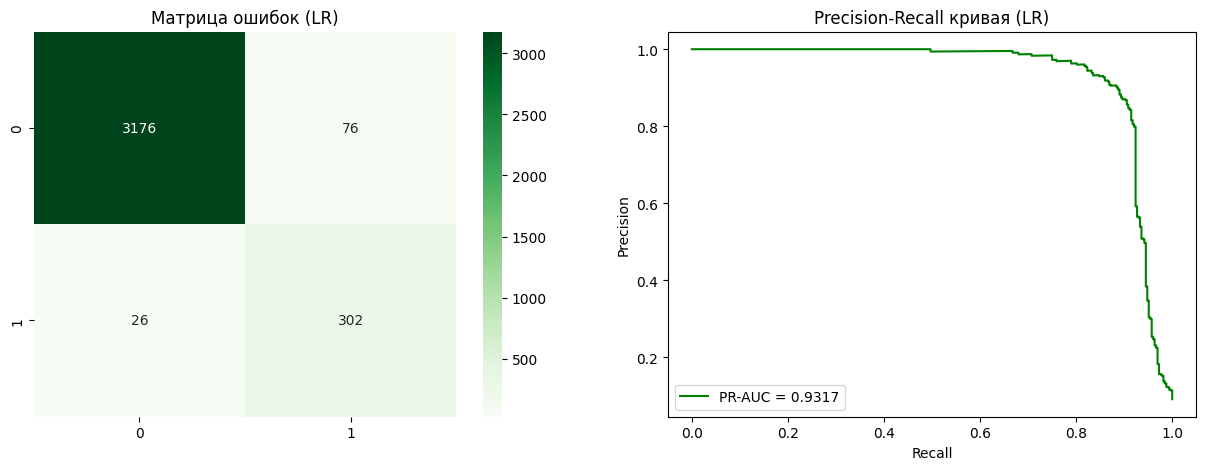

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, f1_score, roc_curve, auc, precision_recall_curve, average_precision_score
import seaborn as sns
import matplotlib.pyplot as plt

# Обучение
model_lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
model_lr.fit(X_train_scaled, y_train)

# Предсказания и вероятности
y_pred_lr = model_lr.predict(X_test_scaled)
y_probs_lr = model_lr.predict_proba(X_test_scaled)[:, 1]

# Метрики
print(classification_report(y_test, y_pred_lr))

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=ax[0])
ax[0].set_title('Матрица ошибок (LR)')

precision, recall, _ = precision_recall_curve(y_test, y_probs_lr)
pr_auc = average_precision_score(y_test, y_probs_lr)
ax[1].plot(recall, precision, color='green', label=f'PR-AUC = {pr_auc:.4f}')
ax[1].set_title('Precision-Recall кривая (LR)')
ax[1].set_xlabel('Recall')
ax[1].set_ylabel('Precision')
ax[1].legend()

plt.show()

### Random Forest

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3252
           1       0.92      0.86      0.89       328

    accuracy                           0.98      3580
   macro avg       0.95      0.93      0.94      3580
weighted avg       0.98      0.98      0.98      3580



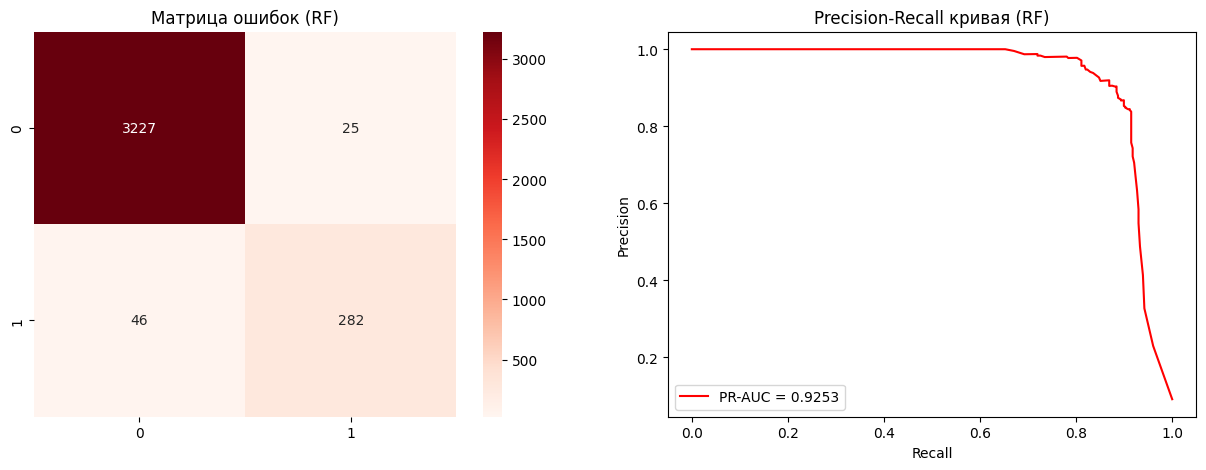

In [8]:
from sklearn.ensemble import RandomForestClassifier

# Обучение
model_rf = RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42)
model_rf.fit(X_train_scaled, y_train)

# Предсказания и вероятности
y_pred_rf = model_rf.predict(X_test_scaled)
y_probs_rf = model_rf.predict_proba(X_test_scaled)[:, 1]

# Метрики
print(classification_report(y_test, y_pred_rf))

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Reds', ax=ax[0])
ax[0].set_title('Матрица ошибок (RF)')

p_rf, r_rf, _ = precision_recall_curve(y_test, y_probs_rf)
pr_auc_rf = average_precision_score(y_test, y_probs_rf)
ax[1].plot(r_rf, p_rf, color='red', label=f'PR-AUC = {pr_auc_rf:.4f}')
ax[1].set_title('Precision-Recall кривая (RF)')
ax[1].set_xlabel('Recall')
ax[1].set_ylabel('Precision')
ax[1].legend()

plt.show()

Стандартный порог классификации (0.5) не оптимален для задач с сильным дисбалансом. Поскольку для нас важно не пропустить пульсар (минимизировать FN), можем снизить порог вероятности, проверим, как уменьшение порога повлияет на полноту (Recall) модели Random Forest

RANDOM FOREST С ПОРОГОМ 0.15
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      3252
           1       0.80      0.91      0.85       328

    accuracy                           0.97      3580
   macro avg       0.90      0.95      0.92      3580
weighted avg       0.97      0.97      0.97      3580



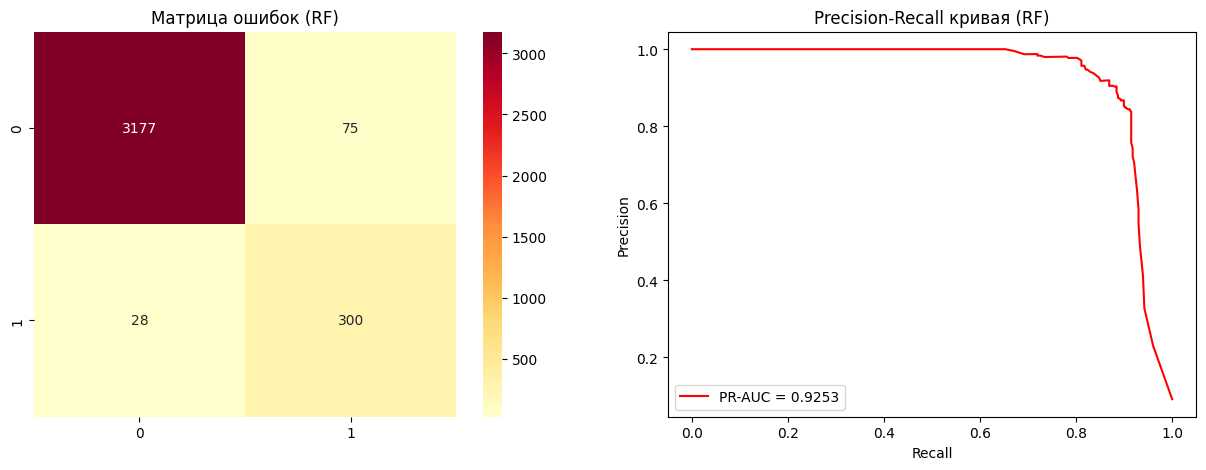

In [19]:
y_probs_rf = model_rf.predict_proba(X_test_scaled)[:, 1] # Берем вероятности из RF

custom_threshold = 0.15 # Порог
y_pred_custom = (y_probs_rf >= custom_threshold).astype(int)

print(f"RANDOM FOREST С ПОРОГОМ {custom_threshold}")
print(classification_report(y_test, y_pred_custom))

# Визуализация
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

cm_rf = confusion_matrix(y_test, y_pred_custom)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='YlOrRd', ax=ax[0])
ax[0].set_title('Матрица ошибок (RF)')

p_rf, r_rf, _ = precision_recall_curve(y_test, y_probs_rf)
pr_auc_rf = average_precision_score(y_test, y_probs_rf)
ax[1].plot(r_rf, p_rf, color='red', label=f'PR-AUC = {pr_auc_rf:.4f}')
ax[1].set_title('Precision-Recall кривая (RF)')
ax[1].set_xlabel('Recall')
ax[1].set_ylabel('Precision')
ax[1].legend()

plt.show()

Снижение порога до 0.15 позволило  увеличить Recall (модель нашла больше пульсаров), однако это привело к росту ложных срабатываний (Precision снизился). Итоговое качество (F1-score и MCC) оказалось ниже, чем у LR.

### Support Vector Machine

              precision    recall  f1-score   support

           0       0.99      0.98      0.98      3252
           1       0.80      0.91      0.85       328

    accuracy                           0.97      3580
   macro avg       0.89      0.94      0.92      3580
weighted avg       0.97      0.97      0.97      3580



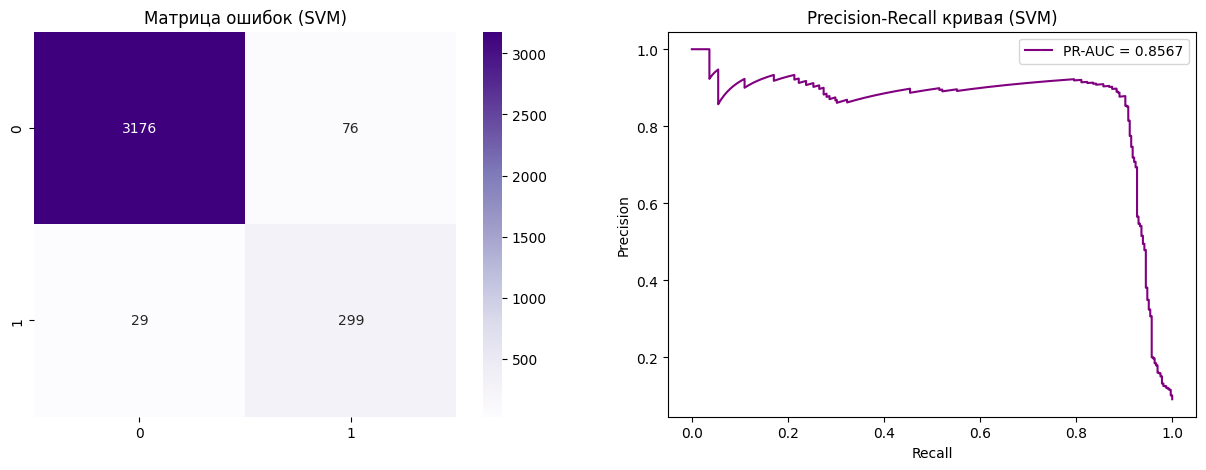

In [9]:
from sklearn.svm import SVC

# Обучение
model_svm = SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42)
model_svm.fit(X_train_scaled, y_train)

# Предсказания
y_pred_svm = model_svm.predict(X_test_scaled)
y_probs_svm = model_svm.predict_proba(X_test_scaled)[:, 1]

# Метрики
print(classification_report(y_test, y_pred_svm))

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

sns.heatmap(confusion_matrix(y_test, y_pred_svm), annot=True, fmt='d', cmap='Purples', ax=ax[0])
ax[0].set_title('Матрица ошибок (SVM)')

p_svm, r_svm, _ = precision_recall_curve(y_test, y_probs_svm)
pr_auc_svm = average_precision_score(y_test, y_probs_svm)
ax[1].plot(r_svm, p_svm, color='purple', label=f'PR-AUC = {pr_auc_svm:.4f}')
ax[1].set_title('Precision-Recall кривая (SVM)')
ax[1].set_xlabel('Recall')
ax[1].set_ylabel('Precision')
ax[1].legend()
plt.show()

### XGBoost

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3252
           1       0.87      0.88      0.88       328

    accuracy                           0.98      3580
   macro avg       0.93      0.94      0.93      3580
weighted avg       0.98      0.98      0.98      3580



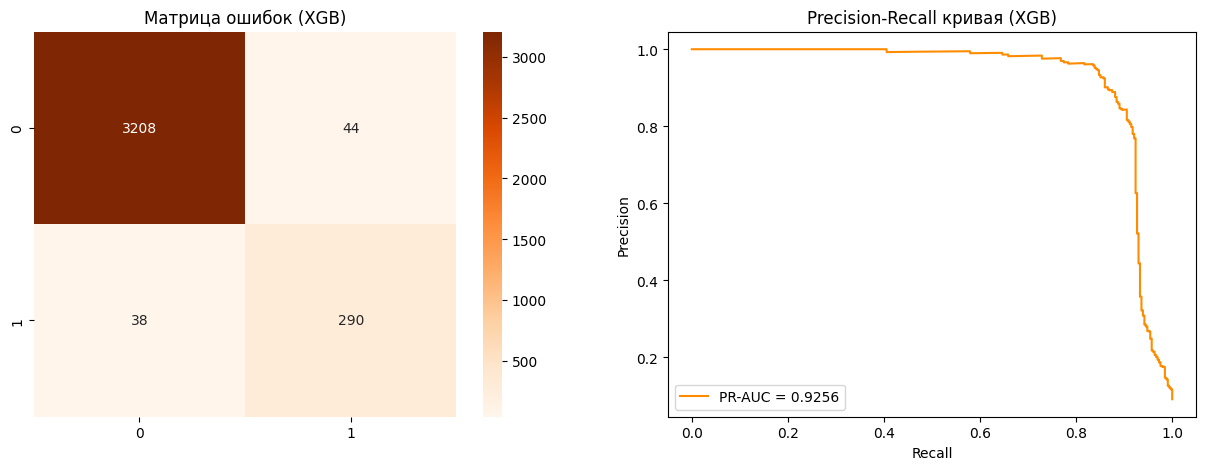

In [6]:
from xgboost import XGBClassifier

# Считаем вес для балансировки: отношение шума к пульсарам
ratio = float(y_train.value_counts()[0] / y_train.value_counts()[1])

# Обучение
model_xgb = XGBClassifier(scale_pos_weight=ratio, random_state=42, eval_metric='logloss')
model_xgb.fit(X_train_scaled, y_train)

# Предсказания
y_pred_xgb = model_xgb.predict(X_test_scaled)
y_probs_xgb = model_xgb.predict_proba(X_test_scaled)[:, 1]

# Метрики
print(classification_report(y_test, y_pred_xgb))

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt='d', cmap='Oranges', ax=ax[0])
ax[0].set_title('Матрица ошибок (XGB)')

p_xgb, r_xgb, _ = precision_recall_curve(y_test, y_probs_xgb)
pr_auc_xgb = average_precision_score(y_test, y_probs_xgb)
ax[1].plot(r_xgb, p_xgb, color='darkorange', label=f'PR-AUC = {pr_auc_xgb:.4f}')
ax[1].set_title('Precision-Recall кривая (XGB)')
ax[1].set_xlabel('Recall')
ax[1].set_ylabel('Precision')
ax[1].legend()
plt.show()

## Сравнение

In [10]:
import pandas as pd
from sklearn.metrics import recall_score, precision_score, f1_score, average_precision_score, classification_report, roc_auc_score, matthews_corrcoef

# Список моделей для сравнения
comparison_list = [
    ('Logistic Regression', model_lr),
    ('Random Forest', model_rf),
    ('SVM', model_svm),
    ('XGBoost', model_xgb)
]

results = []

for name, model in comparison_list:
    y_pred = model.predict(X_test_scaled)
    y_probs = model.predict_proba(X_test_scaled)[:, 1]
    report = classification_report(y_test, y_pred, output_dict=True)

    results.append({
        'Model': name,
        'Recall (Pulsars)': report['1']['recall'],
        'Precision (Pulsars)': report['1']['precision'],
        'F1-Score': report['1']['f1-score'],
        'PR-AUC': average_precision_score(y_test, y_probs),
        'ROC-AUC': roc_auc_score(y_test, y_probs),
        'MCC': matthews_corrcoef(y_test, y_pred)
    })

summary_table = pd.DataFrame(results)
summary_table = summary_table.sort_values(by='Recall (Pulsars)', ascending=False).reset_index(drop=True) # Сортируем по recall

display(summary_table.style.highlight_max(axis=0, color='lightgreen', subset=summary_table.columns[1:]))

,Model,Recall (Pulsars),Precision (Pulsars),F1-Score,PR-AUC,ROC-AUC,MCC
0,Logistic Regression,0.920732,0.798942,0.855524,0.931726,0.971550,0.842409
1,SVM,0.911585,0.797333,0.850640,0.856657,0.965376,0.836760
2,XGBoost,0.884146,0.868263,0.876133,0.925610,0.970421,0.863558
3,Random Forest,0.859756,0.918567,0.888189,0.925300,0.965710,0.877899


Logistic Regression продемонстрировала наилучший показатель Recall (0.9207) и самый высокий PR-AUC (0.9317).

XGBoost показал наиболее сбалансированные результаты. Несмотря на меньший Recall, модель обладает более высоким MCC (0.8635) и F1-Score (0.8761) по сравнению с LR.

Random Forest лидирует по точности (Precision 0.9185) и MCC (0.8778), однако значительно уступает в полноте, пропуская большее количество целевых объектов.

Вывод - **для дальнейшей оптимизации выбраны модели Logistic Regression (как лидер по полноте) и XGBoost (как модель с лучшим балансом характеристик). Целью настройки гиперпараметров будет попытка увеличить Recall при сохранении стабильных значений F1-Score**

# Подбор гиперпараметров

Лучшие параметры LR: {'C': 0.001, 'penalty': 'l2', 'solver': 'liblinear'}
Лучший результат recall: 0.906170725335965
              precision    recall  f1-score   support

           0       0.99      0.94      0.96      3252
           1       0.59      0.90      0.71       328

    accuracy                           0.93      3580
   macro avg       0.79      0.92      0.84      3580
weighted avg       0.95      0.93      0.94      3580



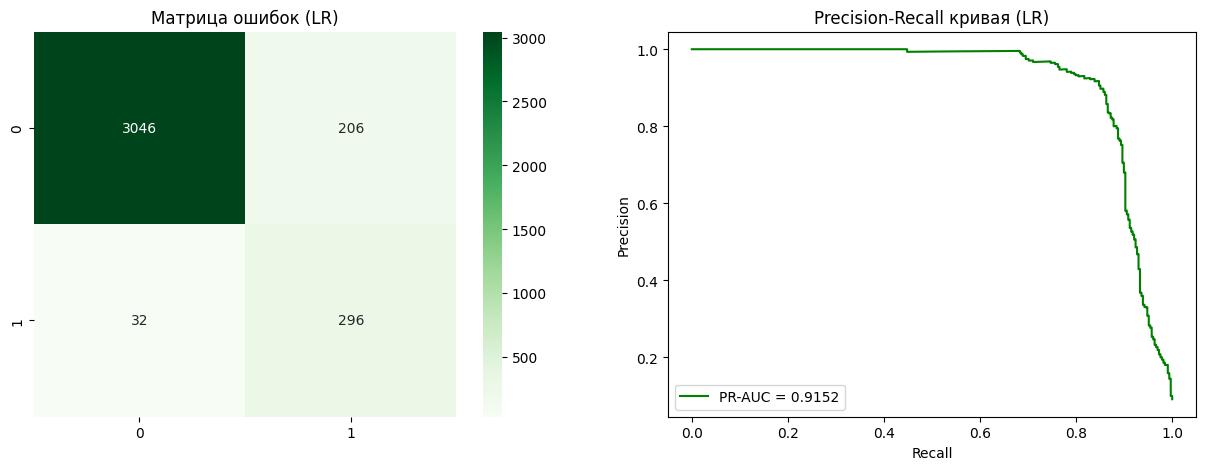

In [11]:
from sklearn.model_selection import GridSearchCV

param_grid_lr = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    # регуляризация, чем меньше C, тем сильнее модель штрафует себя за сложные веса (защита от переобучения)
    'penalty': ['l1', 'l2'],
    # метод наказания модели за сложность: l1 (Lasso) может обнулить веса лишних признаков, l2 (Ridge) просто делает их маленькими
    'solver': ['liblinear', 'saga']
    # алгоритм численной оптимизации, ищет такие коэффициенты модели, при которых ошибка (Log-Loss) будет минимальной
        # liblinear использует метод координатного спуска. Оптимален для малых выборок.
        # saga вариант стохастического градиентного спуска. Поддерживает все типы регуляризации (l1, l2) и работает быстрее на больших объемах данных.
}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    param_grid_lr,
    scoring='recall',
    cv=5,
    n_jobs=-1
)

grid_lr.fit(X_train_scaled, y_train)

print("Лучшие параметры LR:", grid_lr.best_params_)
model_lr_opt = grid_lr.best_estimator_
print("Лучший результат recall:", grid_lr.best_score_)

# Предсказания и вероятности
y_pred_lr_opt = model_lr_opt.predict(X_test_scaled)
y_probs_lr_opt = model_lr_opt.predict_proba(X_test_scaled)[:, 1]

# Метрики
print(classification_report(y_test, y_pred_lr_opt))

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

cm = confusion_matrix(y_test, y_pred_lr_opt)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=ax[0])
ax[0].set_title('Матрица ошибок (LR)')

precision, recall, _ = precision_recall_curve(y_test, y_probs_lr_opt)
pr_auc = average_precision_score(y_test, y_probs_lr_opt)
ax[1].plot(recall, precision, color='green', label=f'PR-AUC = {pr_auc:.4f}')
ax[1].set_title('Precision-Recall кривая (LR)')
ax[1].set_xlabel('Recall')
ax[1].set_ylabel('Precision')
ax[1].legend()

plt.show()

Лучшие параметры XGBoost: {'gamma': 0, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Лучший результат recall: 0.9168461382172814
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      3252
           1       0.73      0.92      0.81       328

    accuracy                           0.96      3580
   macro avg       0.86      0.94      0.90      3580
weighted avg       0.97      0.96      0.96      3580



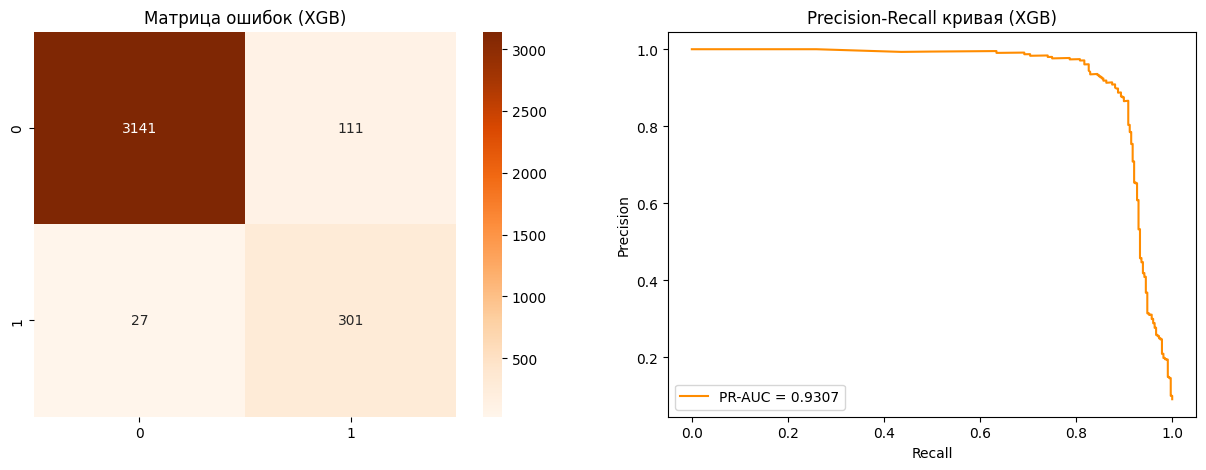

In [13]:
param_grid_xgb = {
    'n_estimators': [100, 200],
    # больше деревьев - выше точность, но дольше учится
    'max_depth': [3, 4, 5],
    # глубина каждого дерева, если дерево слишком глубокое (5 и выше), оно может просто зазубрить тренировочные данные
    'learning_rate': [0.01, 0.05, 0.1],
    # шага обучения, маленький шаг делает обучение точнее, но требует больше деревьев
    'gamma': [0, 0.1, 0.2],
    # Минимальное снижение потерь для создания узла, чем выше, тем сложнее дереву создать новый узел
    'subsample': [0.8, 1.0] # - какой процент данных каждое дерево видит при обучении
}

ratio = float(y_train.value_counts()[0] / y_train.value_counts()[1])

grid_xgb = GridSearchCV(
    XGBClassifier(scale_pos_weight=ratio, random_state=42, eval_metric='logloss'),
    param_grid_xgb,
    scoring='recall',
    cv=5,
    n_jobs=-1
)

grid_xgb.fit(X_train_scaled, y_train)

print("Лучшие параметры XGBoost:", grid_xgb.best_params_)
model_xgb_opt = grid_xgb.best_estimator_
print("Лучший результат recall:", grid_xgb.best_score_)

# Предсказания
y_pred_xgb_opt = model_xgb_opt.predict(X_test_scaled)
y_probs_xgb_opt = model_xgb_opt.predict_proba(X_test_scaled)[:, 1]

# Метрики
print(classification_report(y_test, y_pred_xgb_opt))

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

sns.heatmap(confusion_matrix(y_test, y_pred_xgb_opt), annot=True, fmt='d', cmap='Oranges', ax=ax[0])
ax[0].set_title('Матрица ошибок (XGB)')

p_xgb_opt, r_xgb_opt, _ = precision_recall_curve(y_test, y_probs_xgb_opt)
pr_auc_xgb = average_precision_score(y_test, y_probs_xgb_opt)
ax[1].plot(r_xgb_opt, p_xgb_opt, color='darkorange', label=f'PR-AUC = {pr_auc_xgb:.4f}')
ax[1].set_title('Precision-Recall кривая (XGB)')
ax[1].set_xlabel('Recall')
ax[1].set_ylabel('Precision')
ax[1].legend()
plt.show()

## Сравнение

In [14]:
import pandas as pd
from sklearn.metrics import recall_score, precision_score, f1_score, average_precision_score, classification_report, roc_auc_score, matthews_corrcoef

# Список моделей для сравнения
comparison_list = [
    ('Logistic Regression', model_lr),
    ('Logistic Regression оптимизированная', model_lr_opt),
    ('XGBoost оптимизированная', model_xgb_opt)
]

results = []

for name, model in comparison_list:
    y_pred = model.predict(X_test_scaled)
    y_probs = model.predict_proba(X_test_scaled)[:, 1]
    report = classification_report(y_test, y_pred, output_dict=True)

    results.append({
        'Model': name,
        'Recall (Pulsars)': report['1']['recall'],
        'Precision (Pulsars)': report['1']['precision'],
        'F1-Score': report['1']['f1-score'],
        'PR-AUC': average_precision_score(y_test, y_probs),
        'ROC-AUC': roc_auc_score(y_test, y_probs),
        'MCC': matthews_corrcoef(y_test, y_pred)
    })

summary_table = pd.DataFrame(results)
summary_table = summary_table.sort_values(by='Recall (Pulsars)', ascending=False).reset_index(drop=True) # Сортируем по recall

display(summary_table.style.highlight_max(axis=0, color='lightgreen', subset=summary_table.columns[1:]))

,Model,Recall (Pulsars),Precision (Pulsars),F1-Score,PR-AUC,ROC-AUC,MCC
0,Logistic Regression,0.920732,0.798942,0.855524,0.931726,0.971550,0.842409
1,XGBoost оптимизированная,0.917683,0.730583,0.813514,0.930703,0.977002,0.798734
2,Logistic Regression оптимизированная,0.902439,0.589641,0.713253,0.915181,0.971862,0.697166


На основе сравнения метрик и матриц ошибок классификации сигналов пульсаров **выбрана базовая модель Logistic Regression (с параметрами class_weight='balanced').**

Модель показала наименьшее количество пропусков реальных сигналов (26 FN на тестовой выборке), что важно для минимизации потерь научных данных.

В отличие от оптимизированного XGBoost, логистическая регрессия дает меньше ложных срабатываний (76 против 111 FP), экономя время на последующую проверку кандидатов.

Метрики F1 (0.855) и MCC (0.842) у LR выше, это доказывает, что модель лучше сбалансирована - она ловит максимум сигналов при минимально возможном количестве ошибок.


# Кросс-валидация

In [17]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Инициализируем K-Fold (5 фолдов)
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Считаем Recall (полноту) на каждом фолде
cv_results = cross_val_score(model_lr, X_train_scaled, y_train, cv=skf, scoring='recall')

print(f"Результаты Recall по фолдам: {cv_results}")
print(f"Средний Recall: {cv_results.mean():.4f} (+/- {cv_results.std() * 2:.4f})")

Результаты Recall по фолдам: [0.87878788 0.84732824 0.90076336 0.92366412 0.8778626  0.92366412
 0.93129771 0.90839695 0.94656489 0.92366412]
Средний Recall: 0.9062 (+/- 0.0574)


In [16]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Инициализируем K-Fold (5 фолдов)
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Считаем Recall (полноту) на каждом фолде
cv_results = cross_val_score(model_xgb_opt, X_train_scaled, y_train, cv=skf, scoring='recall')

print(f"Результаты Recall по фолдам: {cv_results}")
print(f"Средний Recall: {cv_results.mean():.4f} (+/- {cv_results.std() * 2:.4f})")

Результаты Recall по фолдам: [0.89393939 0.88549618 0.90839695 0.9389313  0.90839695 0.90839695
 0.94656489 0.91603053 0.95419847 0.93129771]
Средний Recall: 0.9192 (+/- 0.0431)


Кросс-валидация показала, что XGBoost чуть стабильнее (0.919) на разных кусках данных, чем LR (0.906). Но Logistic Regression дает лучший баланс - находит максимум объектов при минимальном уровне «шума».

# Анализ ошибок


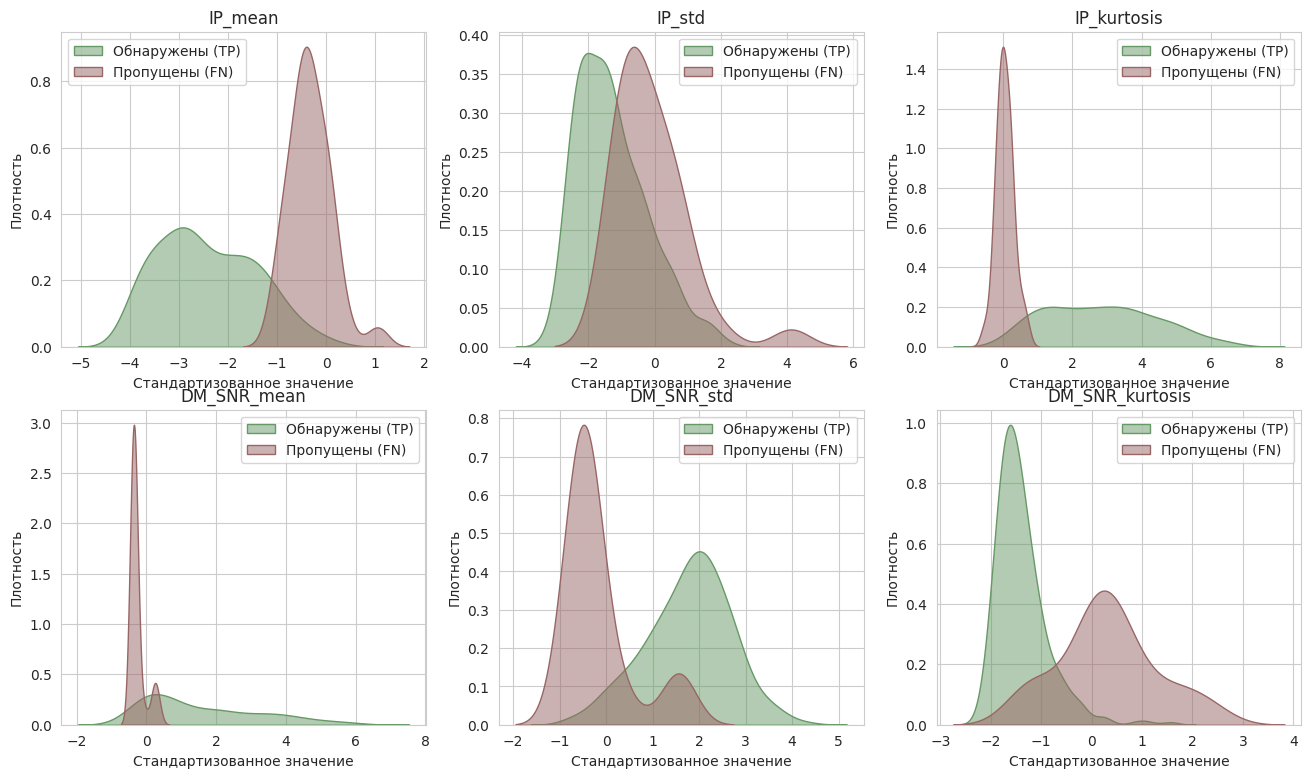

In [39]:
# Подготовка данных
error_analysis = pd.DataFrame(X_test_scaled, columns=X.columns)
error_analysis['true_class'] = y_test.values
error_analysis['pred_class'] = y_pred_lr

# Выделяем найденные и пропущенные
tp = error_analysis[(error_analysis['true_class'] == 1) & (error_analysis['pred_class'] == 1)]
fn = error_analysis[(error_analysis['true_class'] == 1) & (error_analysis['pred_class'] == 0)]

features_final = X.columns
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(features_final):
    sns.kdeplot(tp[col], ax=axes[i], label='Обнаружены (TP)', fill=True, color='#669966', alpha=0.5)
    sns.kdeplot(fn[col], ax=axes[i], label='Пропущены (FN)', fill=True, color='#996666', alpha=0.5)

    axes[i].set_title(f'{col}', fontsize=12)
    axes[i].set_xlabel('Стандартизованное значение')
    axes[i].set_ylabel('Плотность')
    axes[i].legend()
plt.show()

Пропущенные пульсары имеют более высокое значение `IP_mean` и аномально низкий `IP_kurtosis` по сравнению с обнаруженными.

Физически это означает, что их радиосигнал более «размытый» и слабый. Статистически такие объекты почти неотличимы от обычного шума.

Большинство пропусков сосредоточено в зоне пересечения распределений классов. Это говорит о том, что модель сталкивается с физическим пределом данных - для дальнейшего улучшения качества нужны новые, более специфические физические характеристики объектов.